# Heading
Ziel ist die Berechnung der Laufrichtung aus den Daten des Magnetometers.

## Import statements

In [115]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import math
from scipy.spatial.transform import Rotation as R

## Daten einlesen

In [123]:
conn = sqlite3.connect("../data/emi_nav.db")

run_id =  "R2"

df_mag = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'mag'
        ORDER BY timestamp_ms
    """, conn)
df_mag["t_sec"] = (df_mag["timestamp_ms"] - df_mag["timestamp_ms"].min()) / 1000

df_accel = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'accel'
        ORDER BY timestamp_ms
    """, conn)

df_accel["t_sec"] = (df_accel["timestamp_ms"] - df_accel["timestamp_ms"].min()) / 1000

df_gyro = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'gyro'
        ORDER BY timestamp_ms
    """, conn)

df_gyro["t_sec"] = (df_gyro["timestamp_ms"] - df_gyro["timestamp_ms"].min()) / 1000

df_processed = pd.read_sql(
    f"""
        SELECT timestamp_ms, x, y, z FROM imu
        WHERE run_id = '{run_id}' AND sensor = 'imu_processed'
        ORDER BY timestamp_ms
    """, conn)

df_processed["t_sec"] = (df_processed["timestamp_ms"] - df_processed["timestamp_ms"].min()) / 1000

## Integration der Gyro-Daten

Im ersten Schritt werden die drei Achsen des Gyro integriert um die Orientierung des Smartphones zu jedem Zeitpunkt zu erhalten. <br>
Der Gyro misst rad/s, also die Winkelgeschwindigkeit. Durch einfache Integration erhalten wir die Orientierung. Diese Messwerte unterliegen jedoch zufälligem Rauschen. Durch die Integration akkumuliert sich der Fehler, wir beobachten einen sogenannten Drift. Dieser muss später durch Fusion mit dem Magnetometer ausgeglichen werden.<br>

In [127]:
def integrate_gyro(row):
    return row[['x', 'y', 'z']] * row['dt']

def calculate_roll_pitch_yaw(df):
    omega = df[['dx', 'dy', 'dz']].copy().to_numpy(dtype=float)

    # Initial Orientation
    orientation_current = R.identity()

    quaternions = np.zeros((len(omega), 4))   # scipy: [x, y, z, w]
    quaternions[0] = orientation_current.as_quat()

    for i in range(1, len(omega)):
        dq = R.from_rotvec(omega[i])

        orientation_current = orientation_current * dq

        quaternions[i] = orientation_current.as_quat()

    # Eulerwinkel nur zur Ausgabe/Visualisierung
    euler_deg = R.from_quat(quaternions).as_euler('xyz', degrees=True)

    result = pd.DataFrame({
        'roll_deg': euler_deg[:, 0],
        'pitch_deg': euler_deg[:, 1],
        'yaw_deg': euler_deg[:, 2],
    })

    return result

In [128]:
df_gyro['dt'] = df_gyro['t_sec'].diff().fillna(0.0)
df_gyro[['dx', 'dy', 'dz']] = df_gyro.apply(integrate_gyro, axis=1)
df_gyro[['roll', 'pitch', 'yaw']] = calculate_roll_pitch_yaw(df_gyro)
df_gyro

,timestamp_ms,x,y,z,t_sec,dt,dx,dy,dz,roll,pitch,yaw
0,1781614911342,-0.219911,0.177151,-0.084299,0.000,0.000,-0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000
1,1781614911349,-0.166155,0.167377,-0.081856,0.007,0.007,-0.001163,0.001172,-0.000573,-0.066659,0.067111,-0.032869
2,1781614911357,-0.113621,0.168599,-0.081856,0.015,0.008,-0.000909,0.001349,-0.000655,-0.118809,0.144330,-0.070514
3,1781614911365,-0.087965,0.168599,-0.076969,0.023,0.008,-0.000704,0.001349,-0.000616,-0.159242,0.221524,-0.105982
4,1781614911374,-0.062308,0.135612,-0.065973,0.032,0.009,-0.000561,0.001221,-0.000594,-0.191525,0.291350,-0.140216
...,...,...,...,...,...,...,...,...,...,...,...,...
17362,1781615050307,0.667065,-0.304211,-0.007330,138.965,0.008,0.005337,-0.002434,-0.000059,5.009901,-2.566176,-13.635368
17363,1781615050315,0.772134,-0.266337,-0.029322,138.973,0.008,0.006177,-0.002131,-0.000235,5.364941,-2.686541,-13.659816
17364,1781615050323,0.668287,-0.195477,-0.096517,138.981,0.008,0.005346,-0.001564,-0.000772,5.673771,-2.771470,-13.712529
17365,1781615050332,0.401949,-0.112399,-0.163712,138.990,0.009,0.003618,-0.001012,-0.001473,5.885428,-2.820634,-13.802463


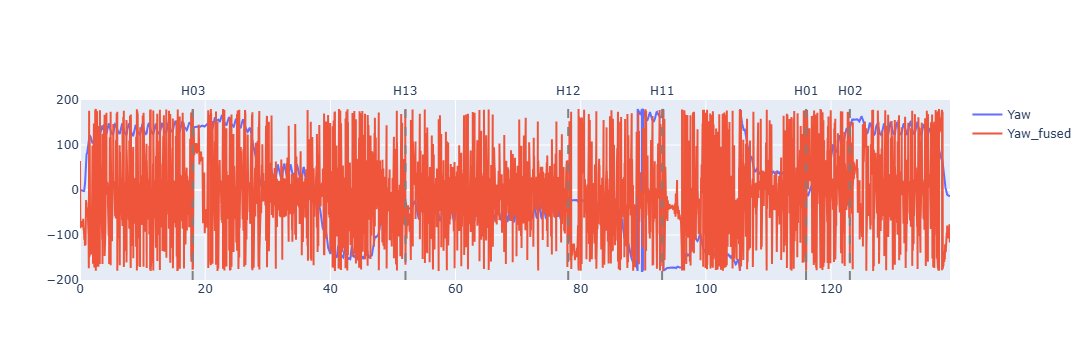

In [129]:
fig=go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_gyro['t_sec'],
        y=df_gyro['yaw'],
        mode='lines',
        name='Yaw'
    )
)

fig.add_trace(
    go.Scatter(
        x=df_processed['t_sec'],
        y=df_processed['x'],
        mode='lines',
        name='Yaw_fused'
    )
)

markers_r2 = {18: 'H03', 52: 'H13', 78: 'H12', 93: 'H11', 116: 'H01', 123: 'H02'}
for x, label in markers_r2.items():
    fig.add_vline(
        x=x,
        line_dash='dash',
        line_color='gray',
        annotation_text=label,
        annotation_position='top'
    )
    
fig.show()